In [1]:
import os
import glob
import os
from scipy.io import mmwrite
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
import psutil
from scipy.stats import zscore
from sklearn.metrics import pairwise_distances

import rmm
import cupy as cp
import cvxpy as cpv
from rmm.allocators.cupy import rmm_cupy_allocator
from cuml.linear_model import ElasticNet

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
%%time

# Load reference
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/cell_type_ref.h5ad"
rdata = sc.read_h5ad(fpath)
rdata.obs['dataset'] = 'reference'
rdata

CPU times: user 21.1 ms, sys: 39.4 ms, total: 60.5 ms
Wall time: 212 ms


AnnData object with n_obs × n_vars = 188 × 28538
    obs: 'cell_type', 'dataset'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'

In [4]:
%%time

# Load our data
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)

adata = sc.get.aggregate(
    adata,
    by='cluster_str',
    func='sum',
    layer='raw_counts',
)

adata.X = adata.layers['sum']
del adata.layers['sum']
adata.obs['cell_type'] = adata.obs['cluster_str']
adata.obs['dataset'] = 'sample'
print(f"{adata.shape=}")

adata

adata.shape=(5, 21412)
CPU times: user 443 ms, sys: 2.02 s, total: 2.46 s
Wall time: 7.11 s


AnnData object with n_obs × n_vars = 5 × 21412
    obs: 'cluster_str', 'cell_type', 'dataset'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_id'

# Normalization/Variance Stabilization

In [5]:
%%time 
rsc.get.anndata_to_GPU(rdata) 
rsc.get.anndata_to_GPU(adata) 

rsc.pp.normalize_total(rdata, target_sum=1e4)
rsc.pp.log1p(rdata)

rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)

rsc.get.anndata_to_CPU(rdata) 
rsc.get.anndata_to_CPU(adata) 

print('done!')

done!
CPU times: user 82.8 ms, sys: 48 ms, total: 131 ms
Wall time: 180 ms


In [6]:
# Step 1: Get intersection of genes
gene_intersection = sorted(set(adata.var_names) & set(rdata.var_names))
print(f"Intersection gene count: {len(gene_intersection)}")

# Step 2: Align both matrices to intersection
adata = adata[: , gene_intersection].copy()
rdata = rdata[: , gene_intersection].copy()

print(f"adata shape: {adata.shape}")
print(f"rdata shape: {rdata.shape}")


Intersection gene count: 16609
adata shape: (5, 16609)
rdata shape: (188, 16609)


#  Distances

In [7]:
adata_ids = np.array(adata.obs_names)
rdata_ids = np.array(rdata.obs_names)
adata_celltypes = np.array(adata.obs['cell_type'])
rdata_celltypes = np.array(rdata.obs['cell_type'])

# Dense matrix conversion
X_adata = adata.X.toarray() if hasattr(adata.X, "toarray") else np.array(adata.X)
X_rdata = rdata.X.toarray() if hasattr(rdata.X, "toarray") else np.array(rdata.X)

metrics = {
    'euclidean': 'euclidean',
    'cosine': 'cosine',
    'correlation': 'correlation',
    'manhattan': 'cityblock',
    'chebyshev': 'chebyshev'
}

result_list = []
for metric_name, metric in metrics.items():
    print(f"Computing pairwise {metric_name} distances...")
    dists = pairwise_distances(X_adata, X_rdata, metric=metric)  # shape (n_adata, n_rdata)
    top10_idx = np.argsort(dists, axis=1)[:, :50]
    top10_dist = np.take_along_axis(dists, top10_idx, axis=1)
    top10_rdata_ids = rdata_ids[top10_idx]
    top10_rdata_celltypes = rdata_celltypes[top10_idx]
    
    rows = []
    for i, adata_id in enumerate(adata_ids):
        for rank in range(50):
            rows.append({
                'adata_id': adata_id,
                'adata_cell_type': adata_celltypes[i],
                'metric': metric_name,
                'rank': rank+1,
                'rdata_id': top10_rdata_ids[i, rank],
                'rdata_cell_type': top10_rdata_celltypes[i, rank],
                'distance': top10_dist[i, rank]
            })
    result_list.extend(rows)

df_result = pd.DataFrame(result_list)
print(df_result.head().to_string())

Computing pairwise euclidean distances...
Computing pairwise cosine distances...
Computing pairwise correlation distances...
Computing pairwise manhattan distances...
Computing pairwise chebyshev distances...
  adata_id adata_cell_type     metric  rank                         rdata_id                  rdata_cell_type   distance
0       C1              C1  euclidean     1             embryonic fibroblast             embryonic fibroblast  34.719944
1       C1              C1  euclidean     2                       fibroblast                       fibroblast  36.247067
2       C1              C1  euclidean     3               myofibroblast cell               myofibroblast cell  36.398938
3       C1              C1  euclidean     4  alveolar type 2 fibroblast cell  alveolar type 2 fibroblast cell  36.495822
4       C1              C1  euclidean     5       endothelial cell of uterus       endothelial cell of uterus  36.544057


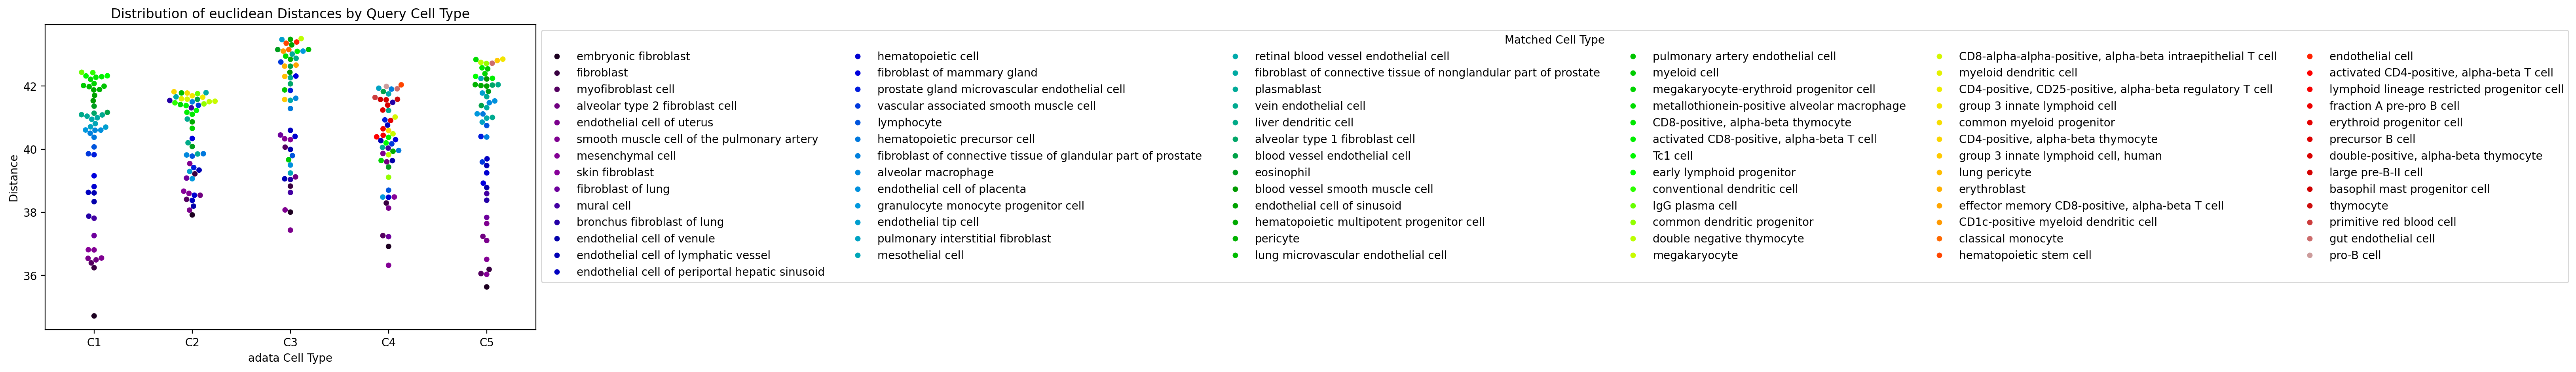

In [8]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 5

metric = 'euclidean'

sns.swarmplot(
    data=df_result[df_result['metric'] == metric],
    x='adata_cell_type', y='distance', hue='rdata_cell_type',
    palette='nipy_spectral'
)
plt.title(f"Distribution of {metric} Distances by Query Cell Type")
plt.xlabel("adata Cell Type")
plt.ylabel("Distance")
plt.legend(title='Matched Cell Type', ncols=6, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


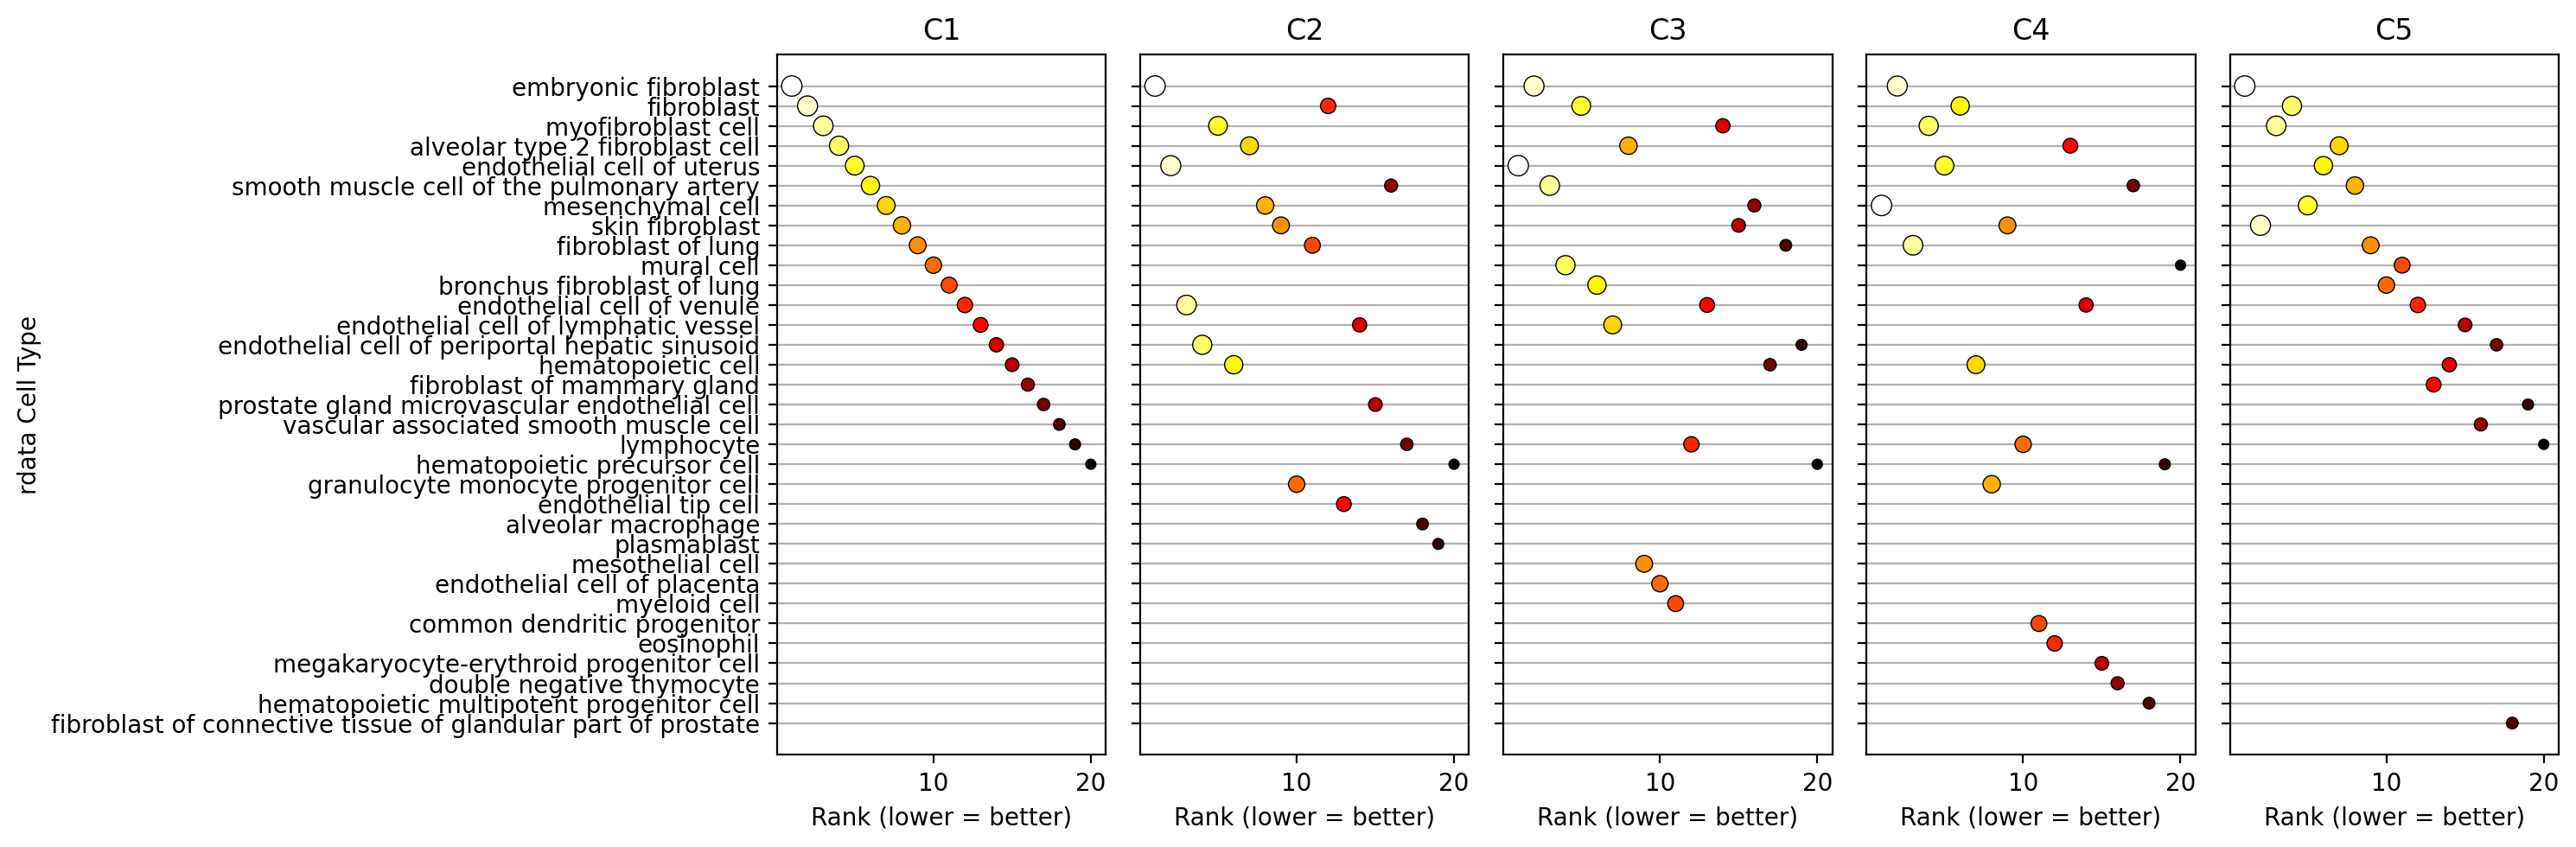

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

metric = 'euclidean'
df_plot = df_result[df_result['metric'] == metric]

# Group and get mean rank for each (adata_cell_type, rdata_cell_type)
mean_ranks = (
    df_plot.groupby(['adata_cell_type', 'rdata_cell_type'])['rank']
    .mean()
    .reset_index()
)

# Get unique adata_cell_types, preserve order as seen in data
adata_types = df_plot['adata_cell_type'].unique()

n_types = len(adata_types)
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)

if n_types == 1:
    axes = [axes]

for i, adata_type in enumerate(adata_types):
    ax = axes[i]
    data = mean_ranks[mean_ranks['adata_cell_type'] == adata_type]
    # Get top 10 rdata_cell_type with lowest mean rank
    top10 = data.nsmallest(20, 'rank')
    top10['size'] = 20 - top10['rank']
    sns.scatterplot(
        data=top10,
        y='rdata_cell_type',
        x='rank',
        ec='k',
        hue='rank',
        palette='hot_r',
        size='size',
        legend=False,
        lw=0.5,
        zorder=4,
        ax=ax,
    )
    ax.set_title(f"{adata_type}")
    ax.yaxis.grid(True)
    ax.set_xlabel('Rank (lower = better)')
    ax.set_ylabel('rdata Cell Type' if i == 0 else '')

plt.tight_layout()
plt.show()


/tmp/ipykernel_3874986/107540266.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_ranks_filtered['size'] = 100  # Uniform size; customize if you want


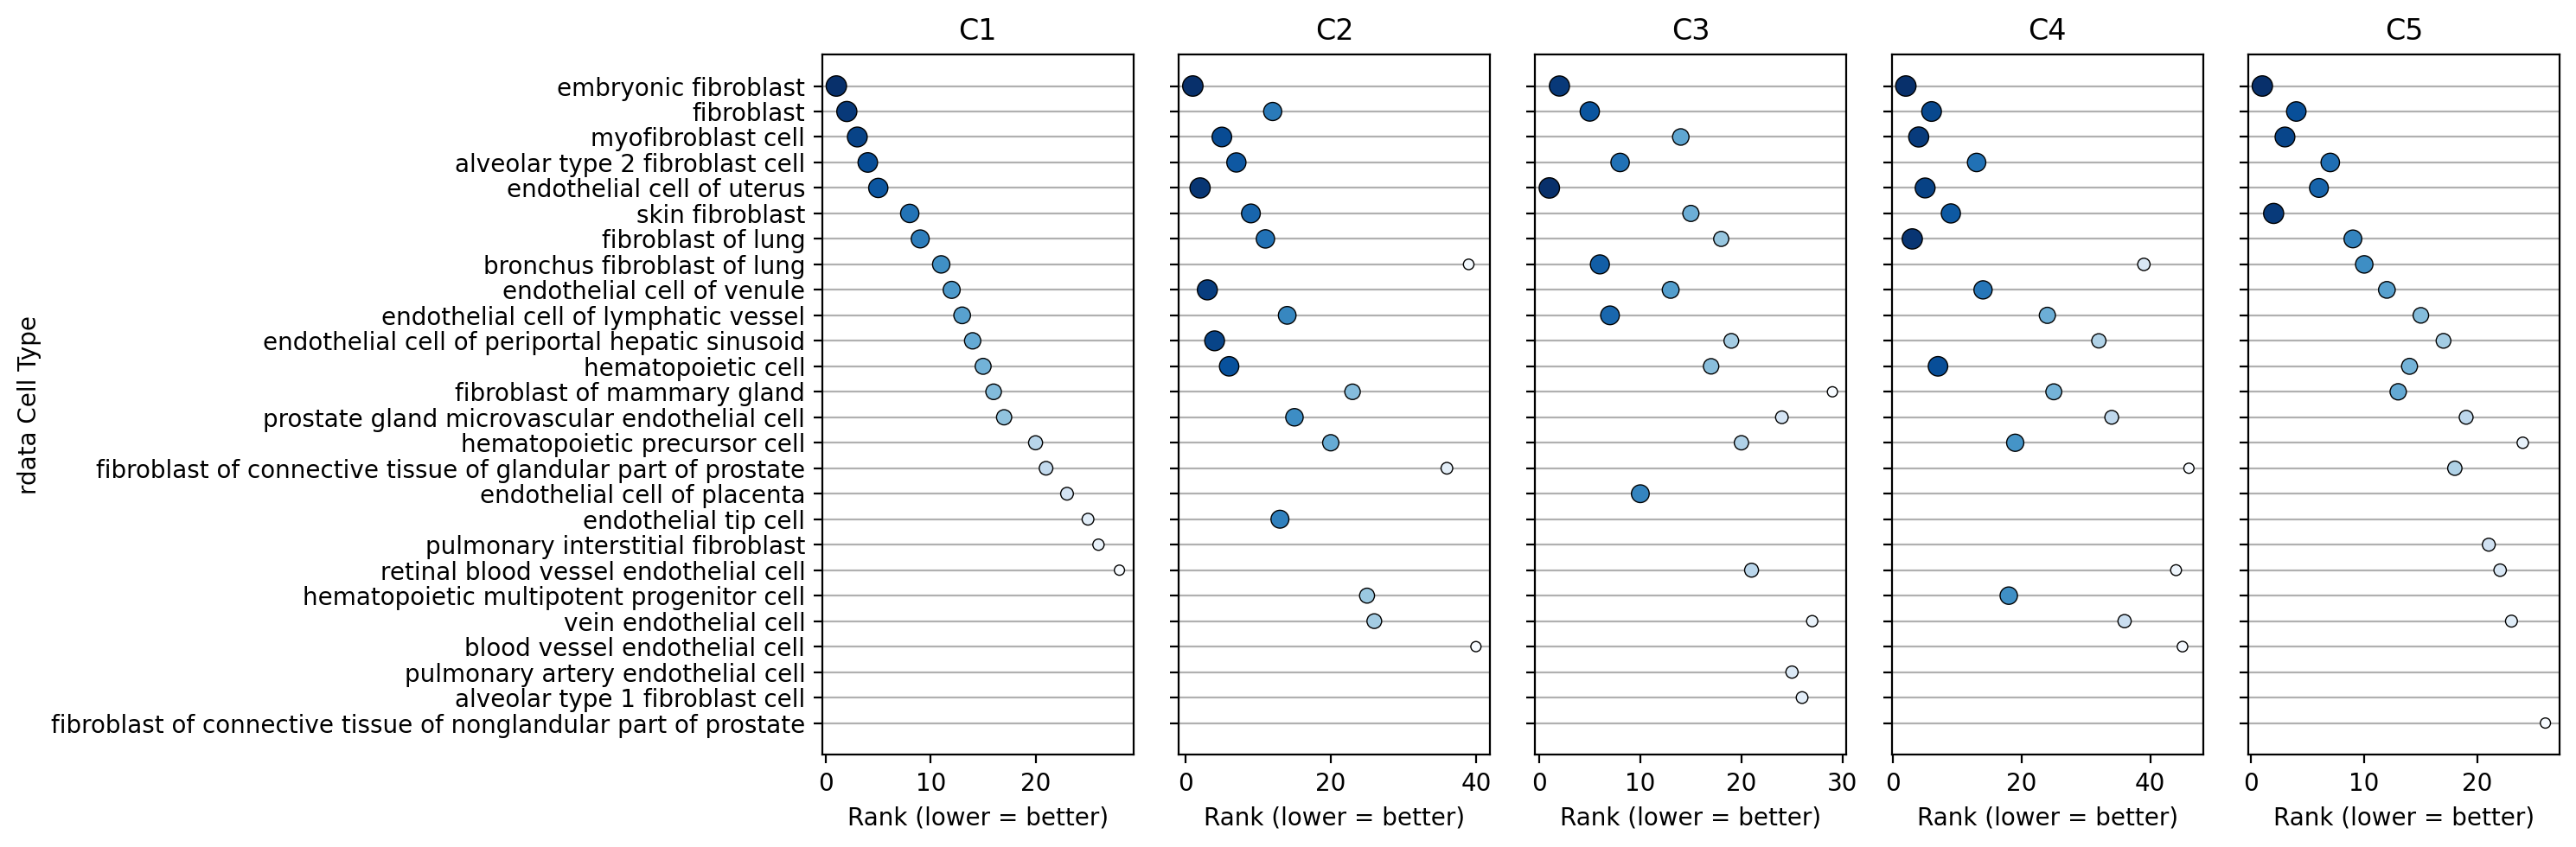

In [10]:
# Keywords to search for (case-insensitive)
keywords = ['fibroblast', 'endothelial', 'hemat']

metric = 'euclidean'
df_plot = df_result[df_result['metric'] == metric]

# Group and get mean rank for each (adata_cell_type, rdata_cell_type)
mean_ranks = (
    df_plot.groupby(['adata_cell_type', 'rdata_cell_type'])['rank']
    .mean()
    .reset_index()
)

# Filter for rdata_cell_type containing keywords
mask = mean_ranks['rdata_cell_type'].str.lower().str.contains('|'.join(keywords))
mean_ranks_filtered = mean_ranks[mask]

# Add a size column for scatterplot point size
mean_ranks_filtered['size'] = 100  # Uniform size; customize if you want

adata_types = df_plot['adata_cell_type'].unique()
n_types = len(adata_types)
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)

if n_types == 1:
    axes = [axes]

for i, adata_type in enumerate(adata_types):
    ax = axes[i]
    data = mean_ranks_filtered[mean_ranks_filtered['adata_cell_type'] == adata_type]
    # Get top 10 rdata_cell_type with lowest mean rank
    top10 = data.nsmallest(20, 'rank')
    top10['size'] = 20 - top10['rank']
    sns.scatterplot(
        data=top10,
        y='rdata_cell_type',
        x='rank',
        ec='k',
        hue='rank',
        palette='Blues_r',
        size='size',
        legend=False,
        lw=0.5,
        zorder=4,
        ax=ax,
    )
    ax.set_title(f"{adata_type}")
    ax.yaxis.grid(True)
    ax.set_xlabel('Rank (lower = better)')
    ax.set_ylabel('rdata Cell Type' if i == 0 else '')

plt.tight_layout()
plt.show()

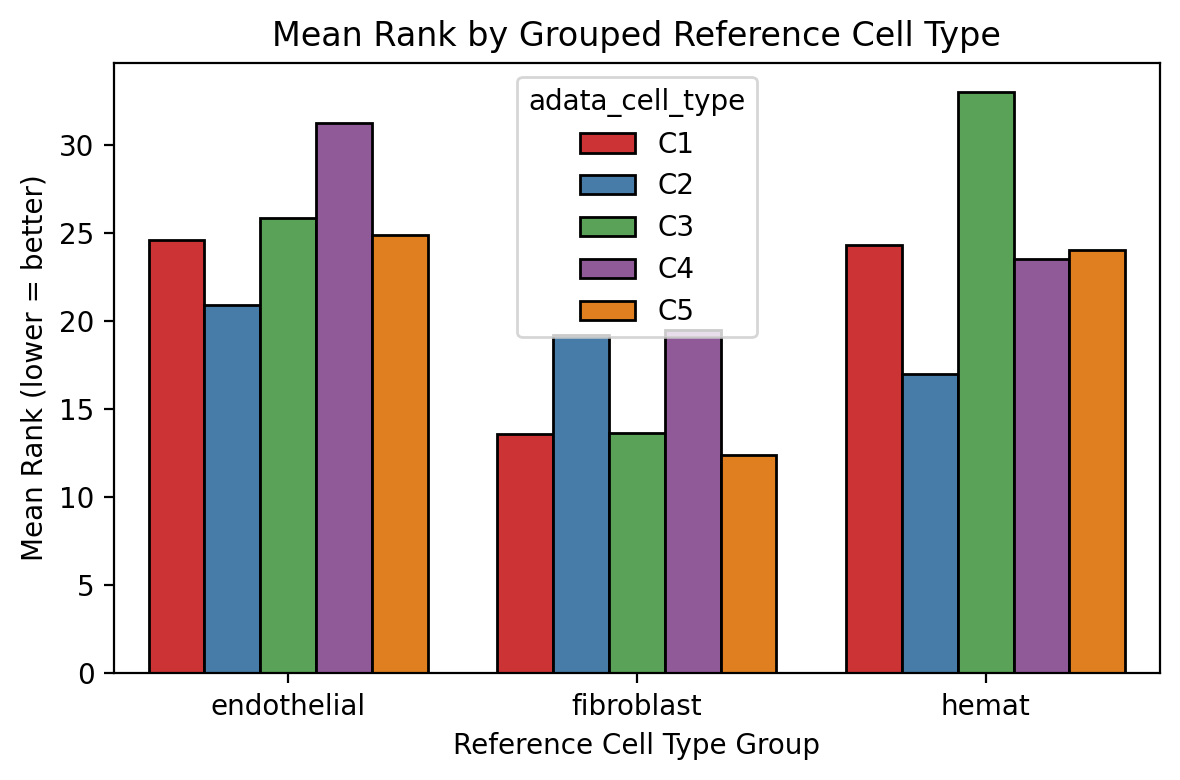

In [11]:
# Assign major group keyword
keywords = ['fibroblast', 'endothelial', 'hemat']
def get_keyword(celltype):
    ct = celltype.lower()
    for k in keywords:
        if k in ct:
            return k
    return None

metric = 'euclidean'
df_plot = df_result[df_result['metric'] == metric]
mean_ranks = (
    df_plot.groupby(['adata_cell_type', 'rdata_cell_type'])['rank']
    .mean()
    .reset_index()
)
mean_ranks['rdata_keyword'] = mean_ranks['rdata_cell_type'].apply(get_keyword)
mean_ranks_kw = mean_ranks.dropna(subset=['rdata_keyword'])

# Compute mean rank for each (adata_cell_type, rdata_keyword)
summary = (
    mean_ranks_kw.groupby(['adata_cell_type', 'rdata_keyword'])['rank']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=summary,
    x='rdata_keyword',
    y='rank',
    hue='adata_cell_type',
    palette='Set1',
    ec='k',
)
plt.xlabel('Reference Cell Type Group')
plt.ylabel('Mean Rank (lower = better)')
plt.title('Mean Rank by Grouped Reference Cell Type')
plt.tight_layout()
plt.show()

## Sparse Linear Fit of Target Profiles Using Reference Profiles

Given:

- $\mathbf{X}_{\text{ref}} \in \mathbb{R}^{n_{\text{ref}} \times g}$:  
  Expression matrix of reference cells (rows = cells, columns = genes), from `rdata`.
- $\mathbf{X}_{\text{target}} \in \mathbb{R}^{n_{\text{target}} \times g}$:  
  Expression matrix of target cells (rows = cells, columns = genes), from `adata`.
- $C_{\text{ref}}$:  
  Cell type annotation for each reference cell.

**Goal:**  
For each target cell $j$ ($1 \leq j \leq n_{\text{target}}$), find a sparse vector of weights $\mathbf{w}_j \in \mathbb{R}^{n_{\text{ref}}}$ such that:

$$
\mathbf{x}_{\text{target},j} \approx \mathbf{X}_{\text{ref}}^\top \mathbf{w}_j
$$

where $\mathbf{x}_{\text{target},j}$ is the gene expression profile of target cell $j$.

**Optimization (Lasso/ElasticNet regression):**

For each target cell $j$, solve:

$$
\mathbf{w}_j = \underset{\mathbf{w}}{\arg\min} \; \left\| \mathbf{x}_{\text{target},j} - \mathbf{X}_{\text{ref}}^\top \mathbf{w} \right\|_2^2 + \alpha \|\mathbf{w}\|_1
$$

where:
- $\alpha$ controls sparsity (higher = sparser).
- $\|\mathbf{w}\|_1$ is the L1 norm.

**Result:**  
- $\mathbf{w}_j$ encodes the contribution of each reference cell to target cell $j$.
- The solution is **sparse**: most weights are zero.
- Each weight can be annotated with the reference cell's type, enabling downstream summaries (e.g., sum/mean of weights by cell type).




Resulting weights DataFrame (shape): (5, 188)
ref_cell  fibroblast
cell_type fibroblast
C1               0.0
C2               0.0
C3               0.0
C4               0.0
C5               0.0

Model error DataFrame (MSE, shape): (5, 1)
         mse
C1  0.049507
C2  0.054561
C3  0.054517
C4  0.054770
C5  0.052533
df.shape=(29, 5)


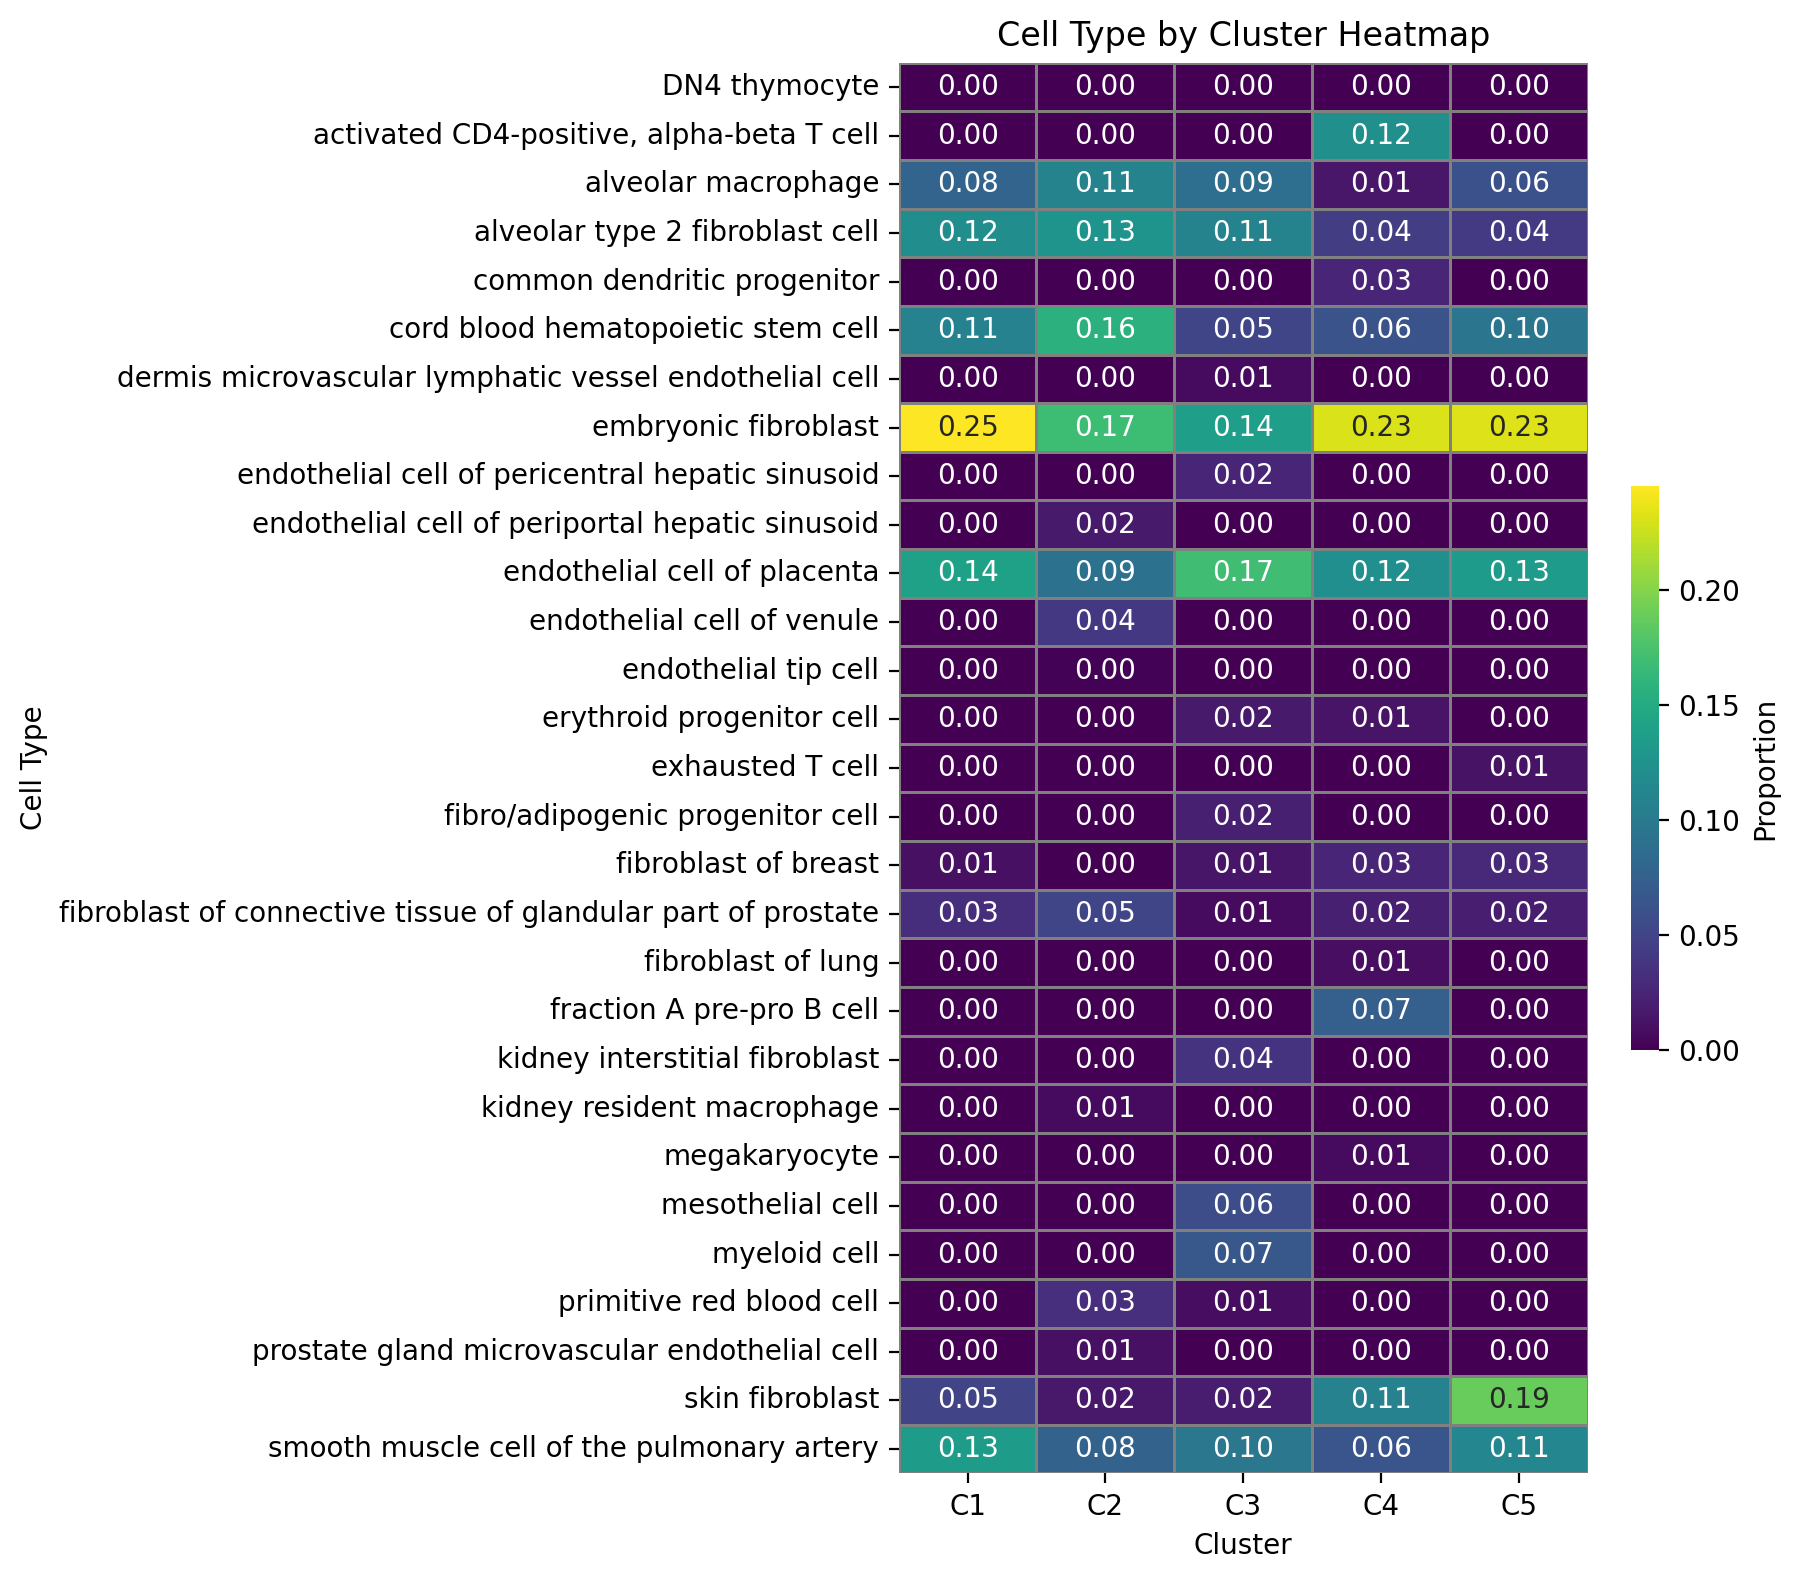

CPU times: user 6.7 s, sys: 280 ms, total: 6.98 s
Wall time: 3.37 s


['DN4 thymocyte',
 'activated CD4-positive, alpha-beta T cell',
 'alveolar macrophage',
 'alveolar type 2 fibroblast cell',
 'common dendritic progenitor',
 'cord blood hematopoietic stem cell',
 'dermis microvascular lymphatic vessel endothelial cell',
 'embryonic fibroblast',
 'endothelial cell of pericentral hepatic sinusoid',
 'endothelial cell of periportal hepatic sinusoid',
 'endothelial cell of placenta',
 'endothelial cell of venule',
 'endothelial tip cell',
 'erythroid progenitor cell',
 'exhausted T cell',
 'fibro/adipogenic progenitor cell',
 'fibroblast of breast',
 'fibroblast of connective tissue of glandular part of prostate',
 'fibroblast of lung',
 'fraction A pre-pro B cell',
 'kidney interstitial fibroblast',
 'kidney resident macrophage',
 'megakaryocyte',
 'mesothelial cell',
 'myeloid cell',
 'primitive red blood cell',
 'prostate gland microvascular endothelial cell',
 'skin fibroblast',
 'smooth muscle cell of the pulmonary artery']

In [12]:
%%time

# ---- Model parameters ----
alpha = 1e-2        # Regularization strength
l1_ratio = 1.0        # L1/L2 mixing (1.0 = pure Lasso)
fit_intercept = False # Whether to fit intercept
max_iter = 1000       # Max optimization steps
# --------------------------

# Prepare reference matrix and metadata
R = rdata.X.toarray() if hasattr(rdata.X, "toarray") else np.array(rdata.X)
ref_names = rdata.obs_names.tolist()
ref_cell_types = rdata.obs['cell_type'].tolist()

# Prepare target matrix
A = adata.X.toarray() if hasattr(adata.X, "toarray") else np.array(adata.X)
target_names = adata.obs_names.tolist()

weights = []
errors = []

for i in range(A.shape[0]):
    x = A[i]
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        fit_intercept=fit_intercept,
        max_iter=max_iter
    )
    model.fit(R.T, x)
    w = model.coef_
    weights.append(w)
    
    # Predict fitted value
    x_pred = np.dot(R.T, w)
    mse = np.mean((x - x_pred) ** 2)
    errors.append(mse)

# Output as DataFrame, with cell type metadata for columns
col_multi = pd.MultiIndex.from_arrays([ref_names, ref_cell_types], names=["ref_cell", "cell_type"])
weights_df = pd.DataFrame(weights, columns=col_multi, index=target_names)

# Error DataFrame
error_df = pd.DataFrame({"mse": errors}, index=target_names)
print("\nResulting weights DataFrame (shape):", weights_df.shape)
print(weights_df[['fibroblast']].head().to_string())
print("\nModel error DataFrame (MSE, shape):", error_df.shape)
print(error_df.head())

df = weights_df.copy()
df = df.T
df = df.reset_index()
df = df.drop(columns=['ref_cell'])
df = df.set_index('cell_type')
df = df[df.sum(axis=1) != 0]
print(f"{df.shape=}")

plt.figure(figsize=(9, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Proportion', 'shrink' : 0.4},
    square=False
)
plt.title("Cell Type by Cluster Heatmap")
plt.ylabel("Cell Type")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

df.index.to_list()


Resulting weights DataFrame (shape): (5, 188)
ref_cell  fibroblast
cell_type fibroblast
C1               0.0
C2               0.0
C3               0.0
C4               0.0
C5               0.0

Model error DataFrame (MSE, shape): (5, 1)
         mse
C1  0.049507
C2  0.054561
C3  0.054517
C4  0.054770
C5  0.052533
df.shape=(29, 5)


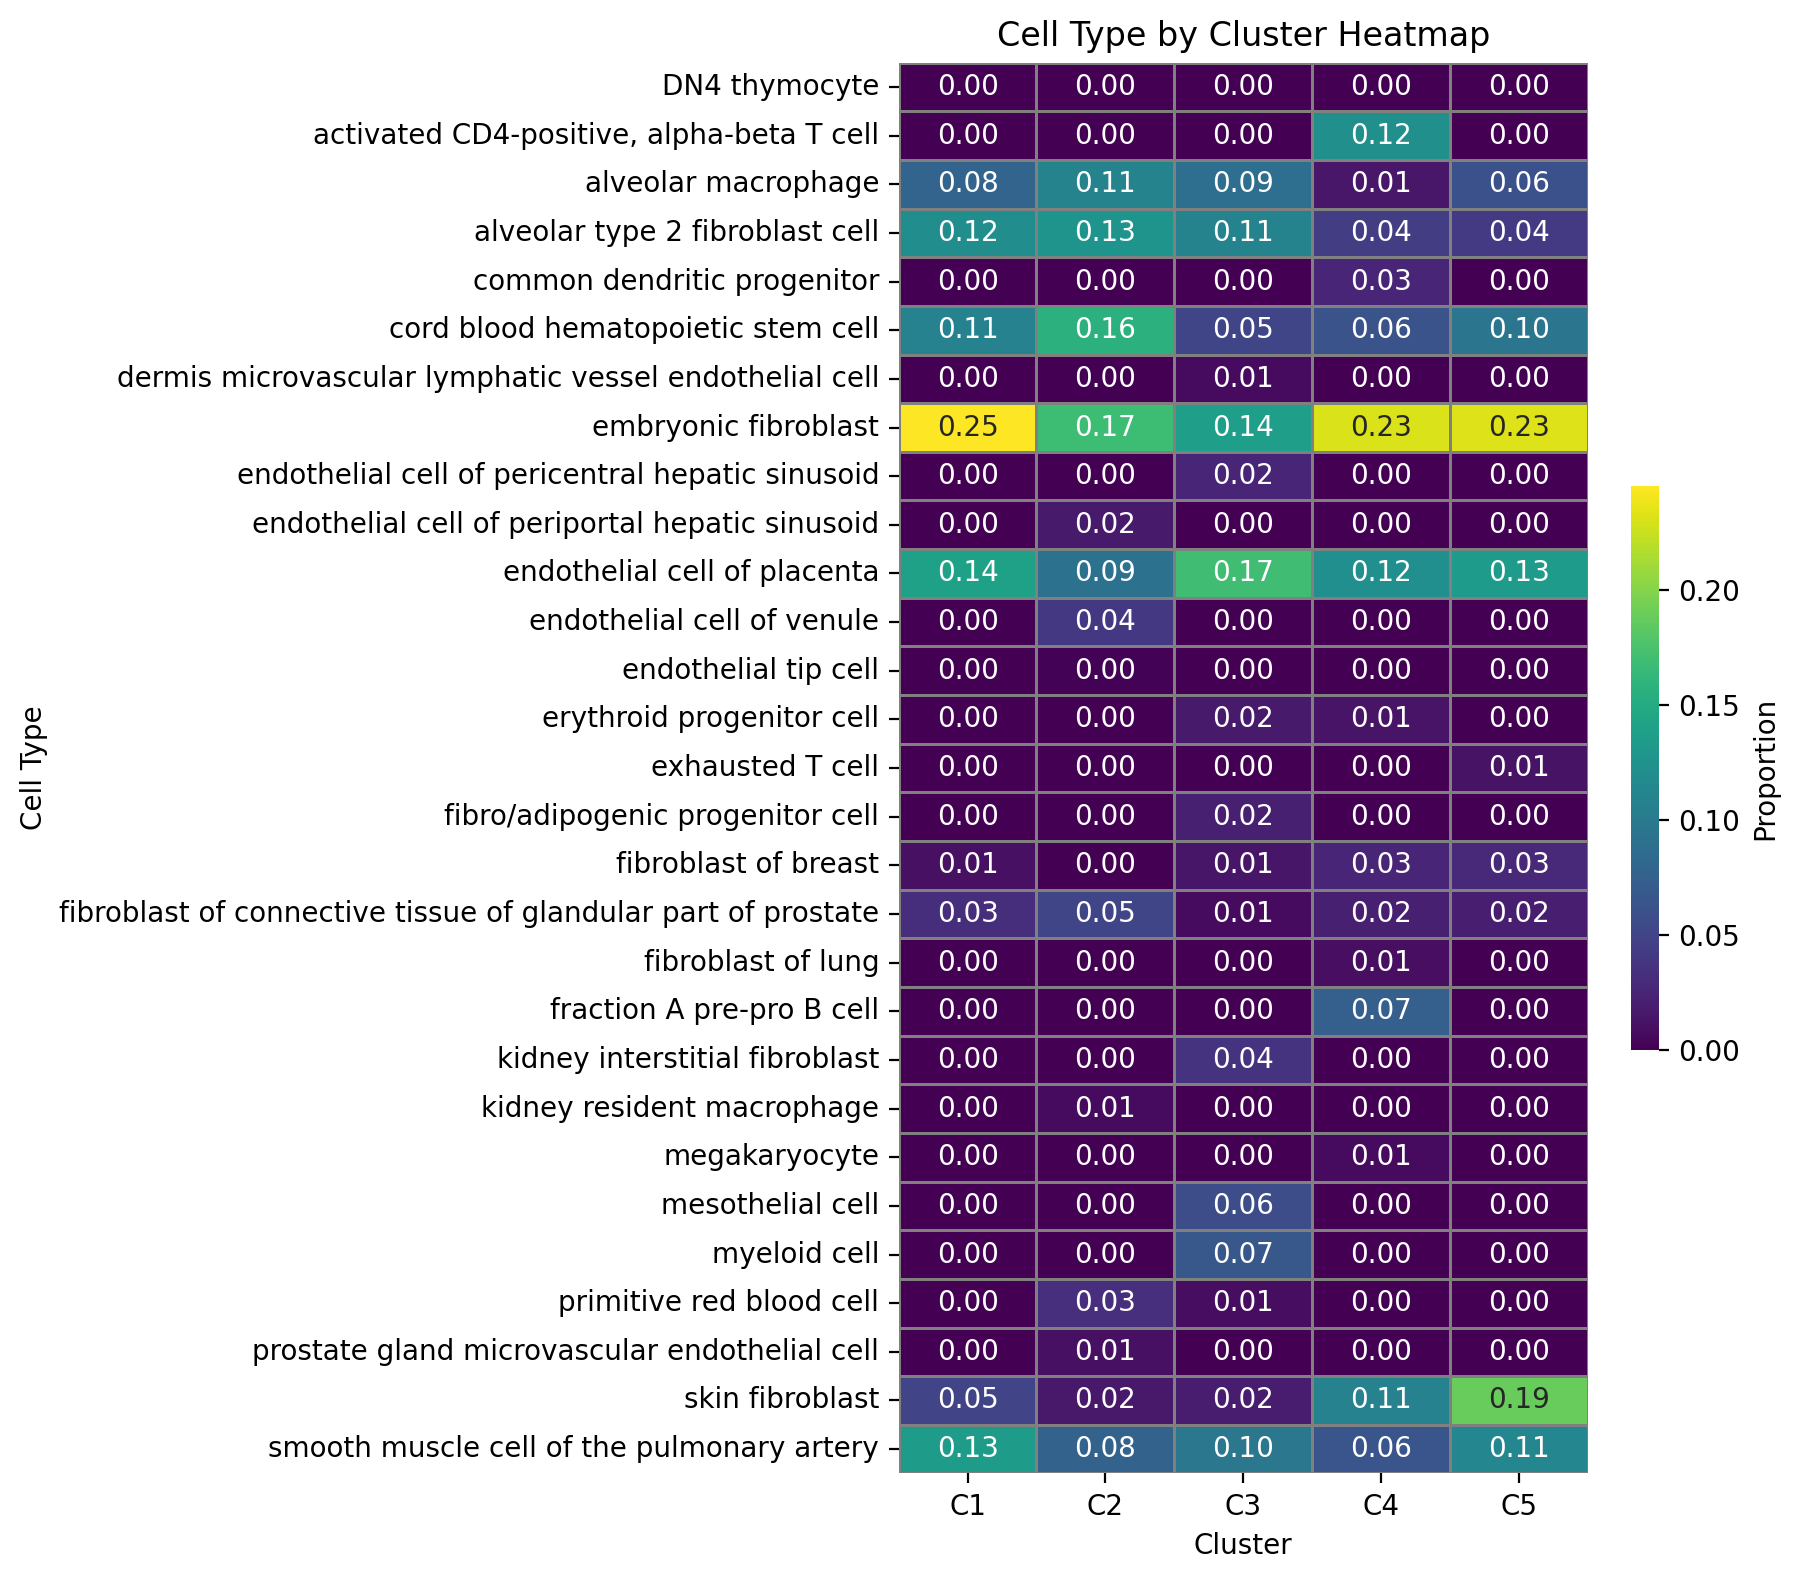

CPU times: user 6.68 s, sys: 244 ms, total: 6.93 s
Wall time: 3.32 s


['DN4 thymocyte',
 'activated CD4-positive, alpha-beta T cell',
 'alveolar macrophage',
 'alveolar type 2 fibroblast cell',
 'common dendritic progenitor',
 'cord blood hematopoietic stem cell',
 'dermis microvascular lymphatic vessel endothelial cell',
 'embryonic fibroblast',
 'endothelial cell of pericentral hepatic sinusoid',
 'endothelial cell of periportal hepatic sinusoid',
 'endothelial cell of placenta',
 'endothelial cell of venule',
 'endothelial tip cell',
 'erythroid progenitor cell',
 'exhausted T cell',
 'fibro/adipogenic progenitor cell',
 'fibroblast of breast',
 'fibroblast of connective tissue of glandular part of prostate',
 'fibroblast of lung',
 'fraction A pre-pro B cell',
 'kidney interstitial fibroblast',
 'kidney resident macrophage',
 'megakaryocyte',
 'mesothelial cell',
 'myeloid cell',
 'primitive red blood cell',
 'prostate gland microvascular endothelial cell',
 'skin fibroblast',
 'smooth muscle cell of the pulmonary artery']

In [13]:
%%time

# ---- Model parameters ----
alpha = 0.01       # Regularization strength
l1_ratio = 1.0        # L1/L2 mixing (1.0 = pure Lasso)
fit_intercept = False # Whether to fit intercept
max_iter = 1000       # Max optimization steps
# --------------------------

# Prepare reference matrix and metadata
R = rdata.X.toarray() if hasattr(rdata.X, "toarray") else np.array(rdata.X)
ref_names = rdata.obs_names.tolist()
ref_cell_types = rdata.obs['cell_type'].tolist()

# Prepare target matrix
A = adata.X.toarray() if hasattr(adata.X, "toarray") else np.array(adata.X)
target_names = adata.obs_names.tolist()

weights = []
errors = []

for i in range(A.shape[0]):
    x = A[i]
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        fit_intercept=fit_intercept,
        max_iter=max_iter
    )
    model.fit(R.T, x)
    w = model.coef_
    weights.append(w)
    
    # Predict fitted value
    x_pred = np.dot(R.T, w)
    mse = np.mean((x - x_pred) ** 2)
    errors.append(mse)

# Output as DataFrame, with cell type metadata for columns
col_multi = pd.MultiIndex.from_arrays([ref_names, ref_cell_types], names=["ref_cell", "cell_type"])
weights_df = pd.DataFrame(weights, columns=col_multi, index=target_names)

# Error DataFrame
error_df = pd.DataFrame({"mse": errors}, index=target_names)
print("\nResulting weights DataFrame (shape):", weights_df.shape)
print(weights_df[['fibroblast']].head().to_string())
print("\nModel error DataFrame (MSE, shape):", error_df.shape)
print(error_df.head())

df = weights_df.copy()
df = df.T
df = df.reset_index()
df = df.drop(columns=['ref_cell'])
df = df.set_index('cell_type')
df = df[df.sum(axis=1) != 0]
print(f"{df.shape=}")

plt.figure(figsize=(9, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Proportion', 'shrink' : 0.4},
    square=False
)
plt.title("Cell Type by Cluster Heatmap")
plt.ylabel("Cell Type")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

df.index.to_list()

# Try removing cell cycle

In [14]:
fpath = "../../../resources/human_cell_cycle_genes.csv"
gdf = pd.read_csv(fpath)
print(f"{gdf.shape=}")

gene_list = gdf['gene_name'].unique()

adata.var['filter_pass'] = ~adata.var.index.isin(gene_list)
rdata.var['filter_pass'] = ~adata.var.index.isin(gene_list)

print('done')

gdf.shape=(142, 7)
done



Resulting weights DataFrame (shape): (5, 188)
ref_cell  fibroblast
cell_type fibroblast
C1               0.0
C2               0.0
C3               0.0
C4               0.0
C5               0.0

Model error DataFrame (MSE, shape): (5, 1)
         mse
C1  0.049426
C2  0.054473
C3  0.054385
C4  0.054391
C5  0.052429
df.shape=(28, 5)


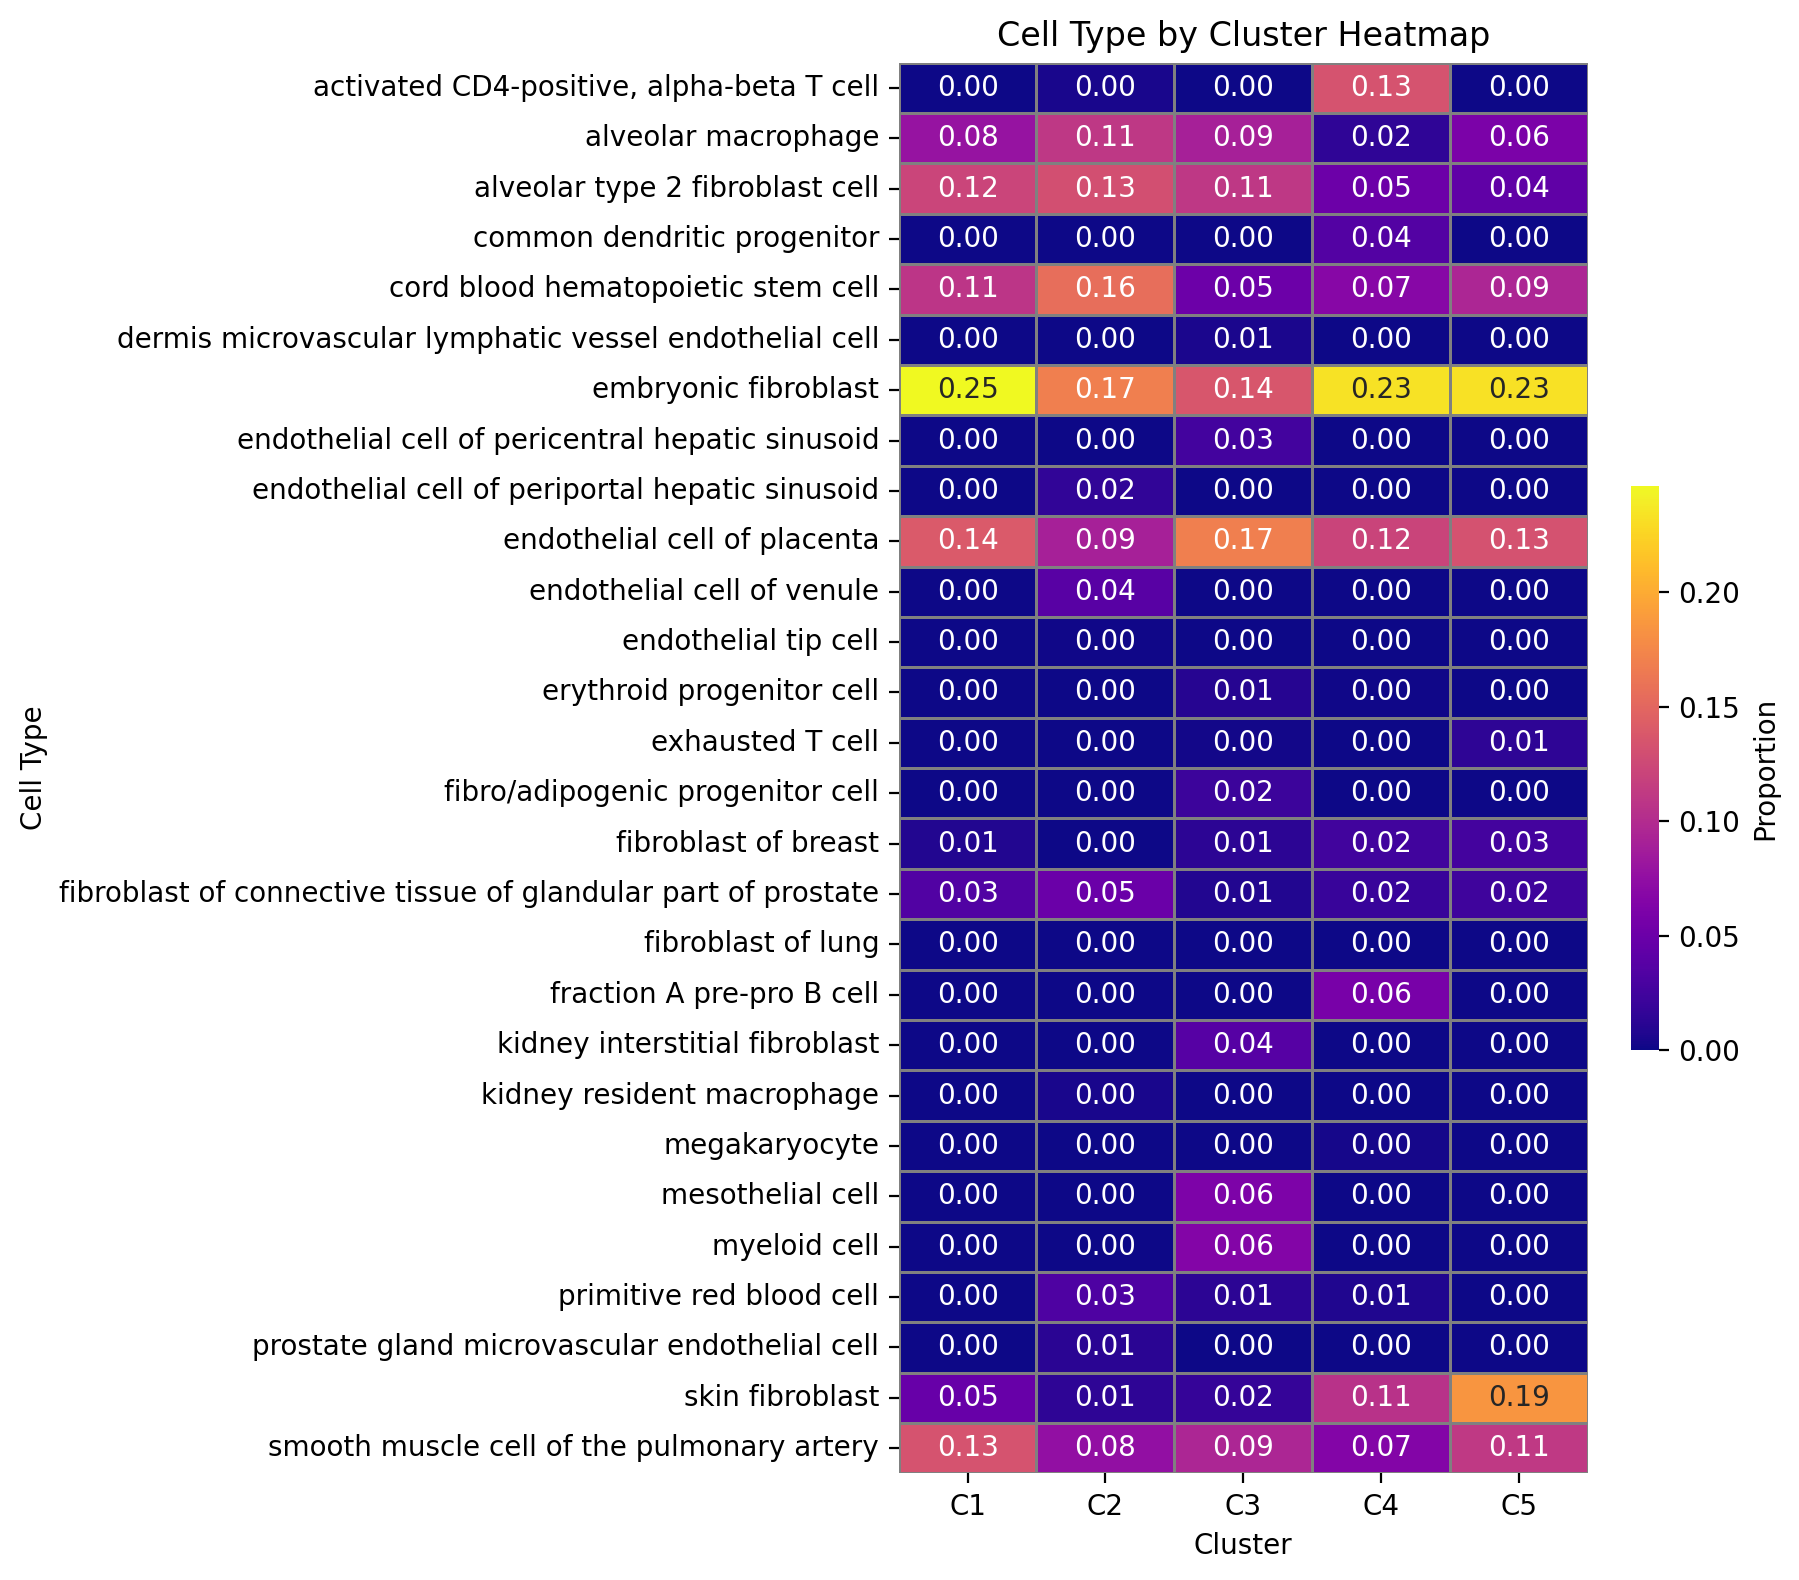

CPU times: user 6.52 s, sys: 256 ms, total: 6.78 s
Wall time: 3.16 s


In [15]:
%%time

# ---- Model parameters ----
alpha = 1e-2          # Regularization strength
l1_ratio = 1.0        # L1/L2 mixing (1.0 = pure Lasso)
fit_intercept = False # Whether to fit intercept
max_iter = 1000       # Max optimization steps
# --------------------------

# ---- Filter genes ----
gene_mask = adata.var['filter_pass'] & rdata.var['filter_pass']
genes_to_use = adata.var_names[gene_mask]

# Subset to filtered genes (columns)
A = adata[:, genes_to_use].X
R = rdata[:, genes_to_use].X

# Convert to dense arrays if needed
A = A.toarray() if hasattr(A, "toarray") else np.array(A)
R = R.toarray() if hasattr(R, "toarray") else np.array(R)

ref_names = rdata.obs_names.tolist()
ref_cell_types = rdata.obs['cell_type'].tolist()
target_names = adata.obs_names.tolist()

weights = []
errors = []

for i in range(A.shape[0]):
    x = A[i]
    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        fit_intercept=fit_intercept,
        max_iter=max_iter
    )
    model.fit(R.T, x)
    w = model.coef_
    weights.append(w)
    
    # Predict fitted value
    x_pred = np.dot(R.T, w)
    mse = np.mean((x - x_pred) ** 2)
    errors.append(mse)

# Output as DataFrame, with cell type metadata for columns
col_multi = pd.MultiIndex.from_arrays([ref_names, ref_cell_types], names=["ref_cell", "cell_type"])
weights_df = pd.DataFrame(weights, columns=col_multi, index=target_names)

# Error DataFrame
error_df = pd.DataFrame({"mse": errors}, index=target_names)
print("\nResulting weights DataFrame (shape):", weights_df.shape)
print(weights_df[['fibroblast']].head().to_string())
print("\nModel error DataFrame (MSE, shape):", error_df.shape)
print(error_df.head())

df = weights_df.copy()
df = df.T
df = df.reset_index()
df = df.drop(columns=['ref_cell'])
df = df.set_index('cell_type')
df = df[df.sum(axis=1) != 0]
print(f"{df.shape=}")

plt.figure(figsize=(9, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="plasma",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Proportion', 'shrink' : 0.4},
    square=False
)
plt.title("Cell Type by Cluster Heatmap")
plt.ylabel("Cell Type")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

In [16]:
df.index.to_list()

['activated CD4-positive, alpha-beta T cell',
 'alveolar macrophage',
 'alveolar type 2 fibroblast cell',
 'common dendritic progenitor',
 'cord blood hematopoietic stem cell',
 'dermis microvascular lymphatic vessel endothelial cell',
 'embryonic fibroblast',
 'endothelial cell of pericentral hepatic sinusoid',
 'endothelial cell of periportal hepatic sinusoid',
 'endothelial cell of placenta',
 'endothelial cell of venule',
 'endothelial tip cell',
 'erythroid progenitor cell',
 'exhausted T cell',
 'fibro/adipogenic progenitor cell',
 'fibroblast of breast',
 'fibroblast of connective tissue of glandular part of prostate',
 'fibroblast of lung',
 'fraction A pre-pro B cell',
 'kidney interstitial fibroblast',
 'kidney resident macrophage',
 'megakaryocyte',
 'mesothelial cell',
 'myeloid cell',
 'primitive red blood cell',
 'prostate gland microvascular endothelial cell',
 'skin fibroblast',
 'smooth muscle cell of the pulmonary artery']

In [17]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)